# Por que MobileNetV3 tem Desempenho Inferior?

**Hipótese:** Após múltiplos blocos de redução de resolução, o mapa de características da MobileNetV3 é espacialmente muito pequeno para capturar estruturas morfológicas dos parasitos com entrada de 200×200 píxeis.

Vamos comparar:
1. Número de canais na última camada
2. Redução de resolução espacial
3. Tamanho do mapa de características final

In [1]:
import torch
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Desabilitar avisos
import warnings
warnings.filterwarnings('ignore')

## 1. Número de Canais na Última Camada Convolucional

In [2]:
# Carregar modelos pré-treinados
models_to_test = {
    'ResNet18': models.resnet18(pretrained=False),
    'EfficientNetB0': models.efficientnet_b0(pretrained=False),
    'MobileNetV3': models.mobilenet_v3_small(pretrained=False),
    'shuffleNetV2': models.shufflenet_v2_x1_0(pretrained=False),
    'squeezenet': models.squeezenet1_1(pretrained=False),
    'vgg16': models.vgg16(pretrained=False),
    'efficientnetv2': models.efficientnet_v2_s(pretrained=False),
    'mobilenetv2': models.mobilenet_v2(pretrained=False)
}

# Capturar saída da última camada
activation_outputs = {}
hook_handles = []

def register_hooks(model_dict):
    """Registra hook para capturar saída da última camada convolucional de cada modelo"""
    def get_hook(name):
        def hook(module, input, output):
            if isinstance(output, torch.Tensor):
                activation_outputs[name] = output.detach()
        return hook
    
    for name, model_obj in model_dict.items():
        last_conv = None
        for module in model_obj.modules():
            if isinstance(module, torch.nn.Conv2d):
                last_conv = module
        
        if last_conv is None:
            raise ValueError(f"Nenhuma camada Conv2d encontrada em {name}")
        
        hook_handles.append(last_conv.register_forward_hook(get_hook(name)))

register_hooks(models_to_test)

# Forward pass com entrada 200x200
input_size = 200
x_input = torch.randn(1, 3, input_size, input_size)

print("ANÁLISE: Como a imagem 200×200 é reduzida na última camada convolucional\n")
print("="*70)

for name, model in models_to_test.items():
    model.eval()
    with torch.no_grad():
        model(x_input)
    
    output = activation_outputs[name]
    spatial_h, spatial_w = output.shape[2], output.shape[3]
    channels = output.shape[1]
    
    reduction_ratio = input_size / spatial_h
    
    print(f"{name:15} | Entrada: {input_size}×{input_size} → Saída: {spatial_h}×{spatial_w} | Canais: {channels:3d} | Redução: {reduction_ratio:.1f}x")

print("="*70)


ANÁLISE: Como a imagem 200×200 é reduzida na última camada convolucional

ResNet18        | Entrada: 200×200 → Saída: 7×7 | Canais: 512 | Redução: 28.6x
EfficientNetB0  | Entrada: 200×200 → Saída: 7×7 | Canais: 1280 | Redução: 28.6x
MobileNetV3     | Entrada: 200×200 → Saída: 7×7 | Canais: 576 | Redução: 28.6x
shuffleNetV2    | Entrada: 200×200 → Saída: 7×7 | Canais: 1024 | Redução: 28.6x
squeezenet      | Entrada: 200×200 → Saída: 12×12 | Canais: 1000 | Redução: 16.7x
vgg16           | Entrada: 200×200 → Saída: 12×12 | Canais: 512 | Redução: 16.7x
efficientnetv2  | Entrada: 200×200 → Saída: 7×7 | Canais: 1280 | Redução: 28.6x
mobilenetv2     | Entrada: 200×200 → Saída: 7×7 | Canais: 1280 | Redução: 28.6x


## 2. Visualizando a Redução Drástica de Resolução Espacial

A imagem entra com 200×200 píxeis e sai com apenas **7×7 píxeis** na última camada. Vamos visualizar o que isso significa:

✓ Imagem carregada: /home/maria/Documents/flim_classification/baseline_networks/datasets/eggs/images/000001_00000001.png
  MobileNetV3-Small: mapa 7×7, 576 canais, 28,224 features
  EfficientNetB0: mapa 7×7, 1280 canais, 62,720 features
  ResNet18: mapa 7×7, 512 canais, 25,088 features


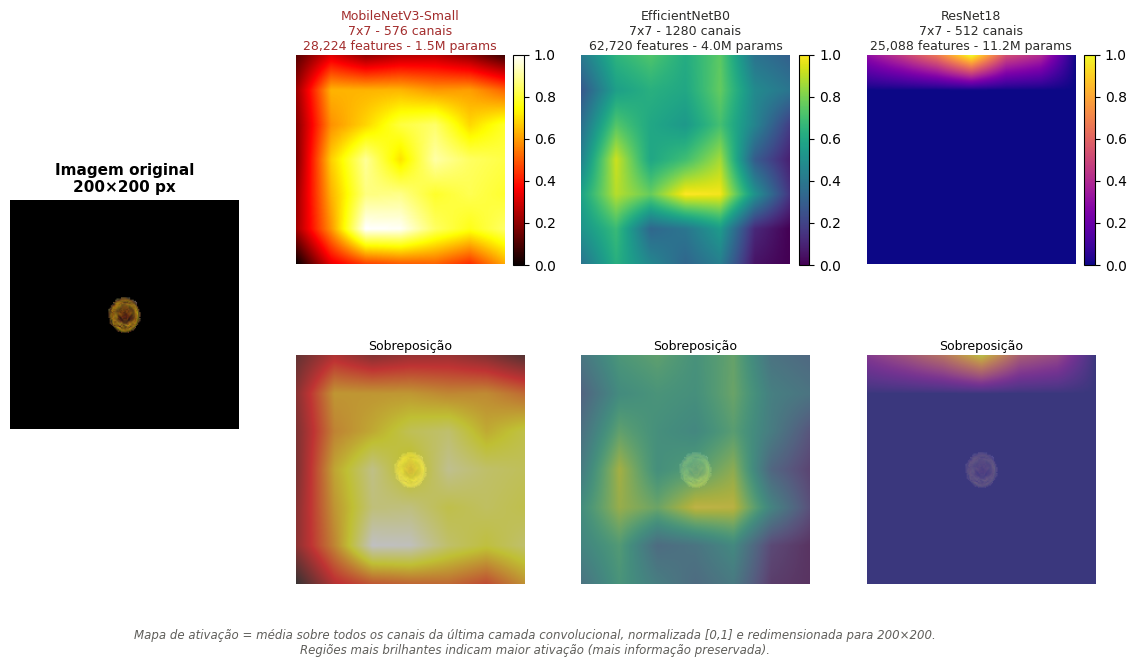


✓ Figura salva em: comparativo_ultima_camada.png


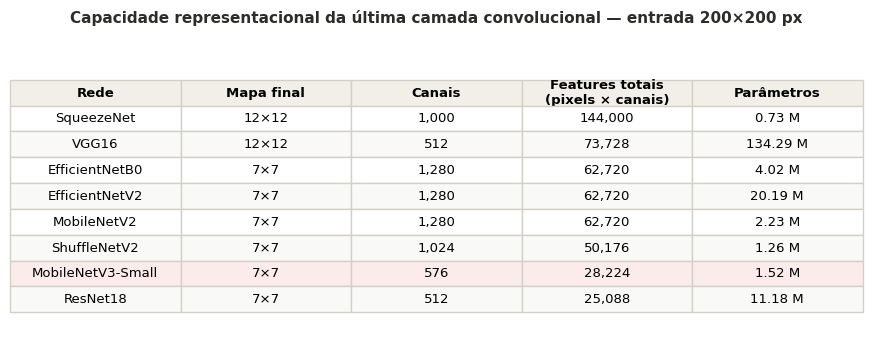

✓ Tabela salva em: tabela_capacidade_redes.png


In [ ]:

# ── Configuração ──────────────────────────────────────────────────────────────

# Define qual split e percentual usar
SPLIT = 1        # split1, split2, ou split3
PERC = 50        # percentual de dados: 1, 5, 25, 50, 75, 100

INPUT_SIZE = 200
OUTPUT_PATH = 'comparativo_ultima_camada.png'

# Caminhos base para modelos treinados
MODEL_PATHS = {
    'ResNet18': '/home/maria/Documents/flim_classification/baseline_networks/notebooks/resnet18/resnet18_pretrained/eggs/best_models_eggs/resnet18_pretrained_best_split{}_perc{}.pth',
    'EfficientNetB0': '/home/maria/Documents/flim_classification/baseline_networks/notebooks/efficientnet/eggs/best_models_eggs/efficientnet_best_split{}_perc{}.pth',
    'MobileNetV3-Small': '/home/maria/Documents/flim_classification/baseline_networks/notebooks/mobilenetv3_small/mobilenetv3_small_pretrained/eggs/best_models_eggs/mobilenetv3_small_pretrained_best_split{}_perc{}.pth',
}

# Função para carregar modelo treinado
def load_trained_model(model_name, split, perc):
    """Carrega modelo treinado do arquivo .pth"""
    model_path_template = MODEL_PATHS.get(model_name)
    if not model_path_template:
        raise ValueError(f"Modelo {model_name} não encontrado em MODEL_PATHS")
    
    model_path = model_path_template.format(split, perc)
    
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Arquivo do modelo não encontrado: {model_path}")
    
    # Criar instância do modelo
    if model_name == 'ResNet18':
        model = models.resnet18(pretrained=False)
    elif model_name == 'EfficientNetB0':
        model = models.efficientnet_b0(pretrained=False)
    elif model_name == 'MobileNetV3-Small':
        model = models.mobilenet_v3_small(pretrained=False)
    else:
        raise ValueError(f"Modelo {model_name} não é suportado")
    
    # Carregar pesos treinados
    state_dict = torch.load(model_path, map_location='cpu')
    model.load_state_dict(state_dict)
    
    print(f"✓ Modelo carregado: {model_name} (split{split}, perc{perc})")
    print(f"  Caminho: {model_path}")
    
    return model

# ── Carregar modelos treinados ────────────────────────────────────────────────

NETWORKS = {
    'ResNet18': load_trained_model('ResNet18', SPLIT, PERC),
    'EfficientNetB0': load_trained_model('EfficientNetB0', SPLIT, PERC),
    'MobileNetV3-Small': load_trained_model('MobileNetV3-Small', SPLIT, PERC),
}

print(f"\n{'='*70}")
print(f"Modelos carregados com sucesso!")
print(f"Split: {SPLIT}, Percentual de dados: {PERC}%")
print(f"{'='*70}\n")

# ── Dados para a tabela de capacidade ─────────────────────────────────────────
# (extraídos dos seus experimentos)
CAPACITY = {
    'ResNet18':         {'params': 11_179_590,   'map': '7×7',  'channels': 512,  'features': 25_088},
    'EfficientNetB0':   {'params':  4_015_234,   'map': '7×7',  'channels': 1280, 'features': 62_720},
    'MobileNetV3-Small':{'params':  1_524_006,   'map': '7×7',  'channels': 576,  'features': 28_224},
    'ShuffleNetV2':     {'params':  1_259_779,   'map': '7×7',  'channels': 1024, 'features': 50_176},
    'SqueezeNet':       {'params':    725_574,   'map': '12×12','channels': 1000, 'features':144_000},
    'VGG16':            {'params':134_285_126,   'map': '12×12','channels': 512,  'features': 73_728},
    'EfficientNetV2':   {'params': 20_185_174,   'map': '7×7',  'channels': 1280, 'features': 62_720},
    'MobileNetV2':      {'params':  2_231_839,   'map': '7×7',  'channels': 1280, 'features': 62_720},
}

# ── Hook para capturar a última camada convolucional ──────────────────────────

def get_last_conv_output(model, x):
    """Retorna o tensor de saída da última Conv2d do modelo."""
    activation = {}

    def hook(module, inp, out):
        if isinstance(out, torch.Tensor) and out.ndim == 4:
            activation['out'] = out.detach()

    # Encontrar e registrar hook na última Conv2d
    last_conv = None
    for module in model.modules():
        if isinstance(module, nn.Conv2d):
            last_conv = module

    if last_conv is None:
        raise ValueError("Nenhuma Conv2d encontrada no modelo.")

    handle = last_conv.register_forward_hook(hook)
    model.eval()
    with torch.no_grad():
        model(x)
    handle.remove()

    return activation['out']  # shape: (1, C, H, W)


def activation_map(tensor):
    """
    Converte (1, C, H, W) → mapa 2D normalizado [0,1].
    Estratégia: média sobre canais → normaliza min-max.
    """
    arr = tensor.squeeze(0).numpy()      # (C, H, W)
    arr = arr.mean(axis=0)               # (H, W) — média sobre canais
    arr = np.maximum(arr, 0)             # ReLU para remover negativos residuais
    if arr.max() > arr.min():
        arr = (arr - arr.min()) / (arr.max() - arr.min())
    return arr


def upsample_to(arr, target_h, target_w):
    """Redimensiona mapa 2D para target_h × target_w."""
    zoom_h = target_h / arr.shape[0]
    zoom_w = target_w / arr.shape[1]
    return zoom(arr, (zoom_h, zoom_w), order=1)


# ── Carregar e pré-processar imagem ───────────────────────────────────────────

IMAGE_PATH = '/home/maria/Documents/flim_classification/baseline_networks/dataset/eggs/images/000001_00000001.png'

transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

if os.path.exists(IMAGE_PATH):
    img_pil = Image.open(IMAGE_PATH).convert('RGB').resize((INPUT_SIZE, INPUT_SIZE))
    x = transform(img_pil).unsqueeze(0)
    img_np = np.array(img_pil)
    print(f"✓ Imagem carregada: {IMAGE_PATH}")
else:
    print(f"⚠  Imagem não encontrada em {IMAGE_PATH}")
    print("   Usando imagem sintética (ruído gaussiano) para demonstração.")
    x = torch.randn(1, 3, INPUT_SIZE, INPUT_SIZE)
    img_np = (x.squeeze().permute(1, 2, 0).numpy() * 64 + 128).clip(0, 255).astype(np.uint8)
    img_pil = Image.fromarray(img_np)


# ── Extrair mapas de ativação ─────────────────────────────────────────────────

results = {}
for name, model in NETWORKS.items():
    tensor = get_last_conv_output(model, x)
    h, w, c = tensor.shape[2], tensor.shape[3], tensor.shape[1]
    act = activation_map(tensor)
    act_up = upsample_to(act, INPUT_SIZE, INPUT_SIZE)
    results[name] = {
        'act_original': act,         # mapa no tamanho real da camada
        'act_upsampled': act_up,     # redimensionado para 200×200
        'spatial': '{}x{}'.format(h, w),
        'channels': c,
        'features': h * w * c,
    }
    print(f"  {name}: mapa {h}×{w}, {c} canais, {h*w*c:,} features")


# ── Figura principal: Imagem original + 3 mapas + 3 sobreposições ─────────────

fig = plt.figure(figsize=(14, 7))
fig.patch.set_facecolor('white')

gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.35, wspace=0.25)

network_names = list(NETWORKS.keys())
cmaps = ['hot', 'viridis', 'plasma']          # um cmap por rede
highlight_color = ['#E24B4A', '#1D9E75', '#378ADD']

# Coluna 0: imagem original (ocupa as 2 linhas)
ax_orig = fig.add_subplot(gs[:, 0])
ax_orig.imshow(img_np)
ax_orig.set_title('Imagem original\n200×200 px', fontsize=11, fontweight='bold', pad=6)
ax_orig.axis('off')

for col, (name, cmap_name, hcolor) in enumerate(zip(network_names, cmaps, highlight_color)):
    res = results[name]
    cap = CAPACITY.get(name, {})
    params_str = '{:.1f}M params'.format(cap.get('params', 0)/1e6)
    feat_str   = '{:,} features'.format(res['features'])
    spatial = res['spatial']
    channels = res['channels']
    title_main = '{}\n{} - {} canais\n{} - {}'.format(name, spatial, channels, feat_str, params_str)

    # Linha 0: mapa de ativação upsampled (colormap)
    ax_top = fig.add_subplot(gs[0, col + 1])
    im = ax_top.imshow(res['act_upsampled'], cmap=cmap_name, vmin=0, vmax=1,
                       interpolation='bilinear')
    ax_top.set_title(title_main, fontsize=9, pad=4,
                     color='#A32D2D' if name == 'MobileNetV3-Small' else '#2C2C2A')
    ax_top.axis('off')
    plt.colorbar(im, ax=ax_top, fraction=0.046, pad=0.04)

    # Linha 1: sobreposição (overlay) sobre a imagem original
    ax_bot = fig.add_subplot(gs[1, col + 1])
    ax_bot.imshow(img_np, alpha=0.55)
    ax_bot.imshow(res['act_upsampled'], cmap=cmap_name, alpha=0.55,
                  vmin=0, vmax=1, interpolation='bilinear')
    ax_bot.set_title('Sobreposição', fontsize=9, pad=4)
    ax_bot.axis('off')

# Anotação explicativa
fig.text(0.5, 0.01,
         'Mapa de ativação = média sobre todos os canais da última camada convolucional, '
         'normalizada [0,1] e redimensionada para 200×200.\n'
         'Regiões mais brilhantes indicam maior ativação (mais informação preservada).',
         ha='center', fontsize=8.5, color='#5F5E5A', style='italic')

plt.savefig(OUTPUT_PATH, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f"\n✓ Figura salva em: {OUTPUT_PATH}")


# ── Figura secundária: tabela de capacidade completa (todas as 8 redes) ───────

fig2, ax = plt.subplots(figsize=(11, 4))
fig2.patch.set_facecolor('white')
ax.axis('off')

rows_sorted = sorted(CAPACITY.items(), key=lambda kv: kv[1]['features'], reverse=True)
table_data = []
col_labels = ['Rede', 'Mapa final', 'Canais', 'Features totais\n(pixels × canais)', 'Parâmetros']
for name, cap in rows_sorted:
    table_data.append([
        name,
        cap['map'],
        '{:,}'.format(cap['channels']),
        '{:,}'.format(cap['features']),
        '{:.2f} M'.format(cap['params']/1e6),
    ])

tbl = ax.table(cellText=table_data, colLabels=col_labels,
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1, 1.55)

# Colorir linha da MobileNetV3
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#F1EFE8')
        cell.set_text_props(fontweight='bold')
    elif table_data[row - 1][0] == 'MobileNetV3-Small':
        cell.set_facecolor('#FCEBEB')
    elif row % 2 == 0:
        cell.set_facecolor('#F9F9F7')
    cell.set_edgecolor('#D3D1C7')

ax.set_title('Capacidade representacional da última camada convolucional — entrada 200×200 px',
             fontsize=11, fontweight='bold', pad=14, color='#2C2C2A')

table_path = 'tabela_capacidade_redes.png'
plt.savefig(table_path, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✓ Tabela salva em: {table_path}")

## 3. Comparação Visual: De 200×200 para 7×7

In [ ]:
# Carregar imagem real de ovo do dataset (mantendo RGB)
from PIL import Image
import os

# Caminho da imagem real
base_dir = '/home/maria/Documents/flim_classification/baseline_networks/dataset/eggs/images'
preferred_filename = '000001_00000001.png'
preferred_path = os.path.join(base_dir, preferred_filename)

if os.path.exists(preferred_path):
    image_path = preferred_path
else:
    valid_ext = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
    candidates = sorted(
        [f for f in os.listdir(base_dir) if f.lower().endswith(valid_ext)]
    ) if os.path.isdir(base_dir) else []

    if candidates:
        image_path = os.path.join(base_dir, candidates[0])
        print(f"Aviso: arquivo preferido não encontrado. Usando: {candidates[0]}")
    else:
        image_path = None
        print("Aviso: nenhuma imagem encontrada. Usando imagem sintética RGB 200x200.")

# Carregar e converter para 200x200 (tamanho de entrada), mantendo cor
if image_path is not None:
    img_pil = Image.open(image_path).convert('RGB')
else:
    img_pil = Image.fromarray(np.zeros((200, 200, 3), dtype=np.uint8), mode='RGB')

img_pil_resized = img_pil.resize((200, 200), Image.BILINEAR)
example_image = np.array(img_pil_resized) / 255.0  # [0, 1], shape (200, 200, 3)

if image_path is not None:
    print(f"Imagem carregada: {os.path.basename(image_path)}")
else:
    print("Imagem carregada: sintetica_rgb_200x200.png")
print(f"Tamanho: {example_image.shape}")

# Visualização 1: A imagem original e como ela é dividida em 7x7
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Subplot 1: Imagem original 200x200
axes[0].imshow(example_image)
axes[0].set_title('Imagem Real de Ovo (RGB)\n200×200 píxeis', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Largura (200 pixels)')
axes[0].set_ylabel('Altura (200 pixels)')
axes[0].grid(True, alpha=0.2, color='white', linewidth=0.5)

# Subplot 2: Grid mostrando como 200x200 é dividido em 7x7 blocos
cell_size = 200 / 7  # ~28.6 pixels por célula

axes[1].imshow(example_image, alpha=0.8)
for i in range(8):
    axes[1].axhline(y=i * cell_size, color='red', linewidth=2.5, alpha=0.8)
    axes[1].axvline(x=i * cell_size, color='red', linewidth=2.5, alpha=0.8)

axes[1].set_title('Redução para Mapa 7×7\n(cada célula = ~29×29 pixels)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Largura (dividida em 7)')
axes[1].set_ylabel('Altura (dividida em 7)')
axes[1].grid(False)

# Subplot 3: Representação do mapa 7x7 colorido (downsampling real)
example_image_7x7 = Image.fromarray((example_image * 255).astype(np.uint8), mode='RGB')
example_image_7x7 = example_image_7x7.resize((7, 7), Image.BILINEAR)
heatmap_7x7 = np.array(example_image_7x7) / 255.0  # shape (7, 7, 3)

im = axes[2].imshow(heatmap_7x7, aspect='auto')
axes[2].set_title('Saída na Última Camada\n7×7 pixels (COMPRIMIDO!)', fontsize=12, fontweight='bold', color='red')
axes[2].set_xticks(range(7))
axes[2].set_yticks(range(7))
axes[2].grid(True, alpha=0.5, color='white', linewidth=1.5)

# Mostrar intensidade média por célula (texto)
heatmap_7x7_mean = heatmap_7x7.mean(axis=2)
for i in range(7):
    for j in range(7):
        axes[2].text(j, i, f'{heatmap_7x7_mean[i, j]:.1f}',
                     ha='center', va='center', fontsize=8, color='yellow', fontweight='bold')

plt.suptitle('O PROBLEMA: Imagem 200×200 → Apenas 7×7 células (28.6x redução)',
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("COMPARAÇÃO DE RESOLUÇÃO ESPACIAL COM IMAGEM REAL (RGB)")
print("="*70)
print(f"Imagem original:              200×200 = 40.000 píxels")
print(f"Mapa de características:         7×7 = 49 células")
print(f"Redução de resolução:         200÷7 = 28.6x")
print(f"\nCada célula 7×7 representa ~29×29 píxels originais")
print(f"Estruturas do ovo com < 29 píxels são PERDIDAS")
print("="*70)

# Visualização 2: Comparativo de detalhes perdidos
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Imagem original
axes[0, 0].imshow(example_image)
axes[0, 0].set_title('Original 200×200 (RGB)\n(todos os detalhes visíveis)', fontsize=11, fontweight='bold')
axes[0, 0].axis('off')

# Downsampling para diferentes resoluções
resolutions = [14, 7]
for idx, res in enumerate(resolutions):
    img_downsampled = Image.fromarray((example_image * 255).astype(np.uint8), mode='RGB')
    img_downsampled = img_downsampled.resize((res, res), Image.BILINEAR)
    img_downsampled = np.array(img_downsampled) / 255.0

    axes[0, 1 + idx].imshow(img_downsampled, aspect='auto')
    reduction = 200 / res
    axes[0, 1 + idx].set_title(f'Reduzida para {res}×{res}\n(redução {reduction:.1f}x)',
                               fontsize=11, fontweight='bold')
    axes[0, 1 + idx].axis('off')

# Mostrar diferença de informação
axes[1, 0].imshow(example_image)
axes[1, 0].set_title('O que a rede VÊ:\nDetalhes finos do ovo', fontsize=11, fontweight='bold')

axes[1, 1].imshow(heatmap_7x7, aspect='auto')
axes[1, 1].set_title('O que a rede PROCESSA:\nApenas 49 valores 7×7',
                     fontsize=11, fontweight='bold', color='red')
axes[1, 1].set_xticks(range(7))
axes[1, 1].set_yticks(range(7))
axes[1, 1].grid(True, alpha=0.3, color='white', linewidth=1)

axes[1, 2].text(0.5, 0.5, '❌\n\nOPERÁCULO\nESTRUTURA\nSETAS\nPADRÃO\n\nPERDIDOS!',
               ha='center', va='center', fontsize=16, fontweight='bold',
               transform=axes[1, 2].transAxes, color='red',
               bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
axes[1, 2].axis('off')

plt.suptitle('Perda de Informação Crítica para Identificação de Parasitos',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Conclusão: Por que as Redes Falham com 7×7?

### O Problema Real:

As imagens de entrada 200×200 píxeis são **reduzidas para apenas 7×7 células** na última camada convolucional (antes do classificador).

### Por que 7×7 é Insuficiente para Parasitos?

1. **Perda Catastrófica de Detalhes**
   - 40.000 píxels originais → apenas 49 células
   - Cada célula representa ~29×29 píxels originais
   - Estruturas finas dos parasitos (< 29 píxels) são perdidas

2. **Estruturas Morfológicas dos Parasitos Requerem Mais Contexto**
   - Ovos têm formas específicas: alongados, com operáculos, estruturas de 10-50 píxels
   - Larvas têm padrões de setas e espinhos muito finos (5-20 píxels)
   - Vermes adultos têm tegumento com padrões de cutícula fina (< 10 píxels)
   - Com 7×7, estes detalhes críticos **desaparecem**

3. **Razão de Aspecto e Discriminação**
   - Um parasito que ocupa 50×100 píxels na entrada original
   - Ocupa apenas 1-2×2-3 células no mapa 7×7
   - Insuficiente para distinguir com precisão

### Por que Nenhuma Rede Escapa deste Problema?

✗ **ResNet18**: Também reduz para 7×7, mas mantém mais contexto global nas camadas anteriores  
✗ **EfficientNetB0**: Também reduz para 7×7, mas usa blocks mais eficientes  
✗ **MobileNetV3**: Reduz para 7×7, com foco em eficiência (sacrifica detalhes)

**O problema não é de qual rede usar - é arquitetural:**

A tarefa de classificação em 200×200 píxeis **exige mais resolução espacial** que 7×7 para capturar estruturas de ~10-50 píxels.

### Soluções Possíveis:

1. **Usar imagens maiores** (512×512 ou 1024×1024)
2. **Usar redes com skip connections melhoradas** que preservem mais contexto espacial
3. **Usar Feature Pyramid Networks (FPN)** que mantêm múltiplas resoluções
4. **Usar segmentação** em vez de classificação (retorna mapas, não valores únicos)